In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Genes encontrados para el análisis: ['XIST', 'KDM6A', 'EIF1AX', 'RPS4Y1', 'DDX3Y', 'NLRP2', 'CYP19A1']


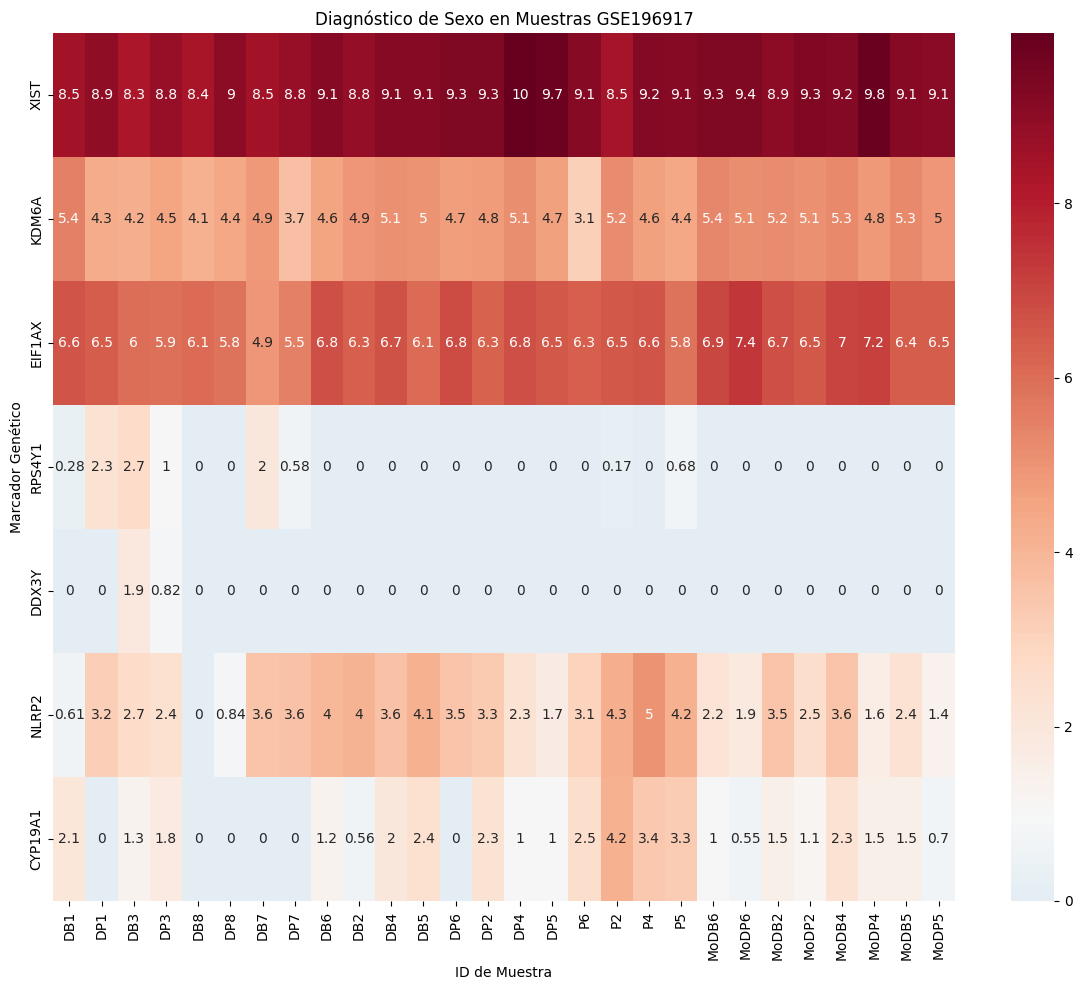


--- Análisis de XIST en Placenta ---
Name      XIST
P6    9.116578
P2    8.460665
P4    9.190421
P5    9.100290


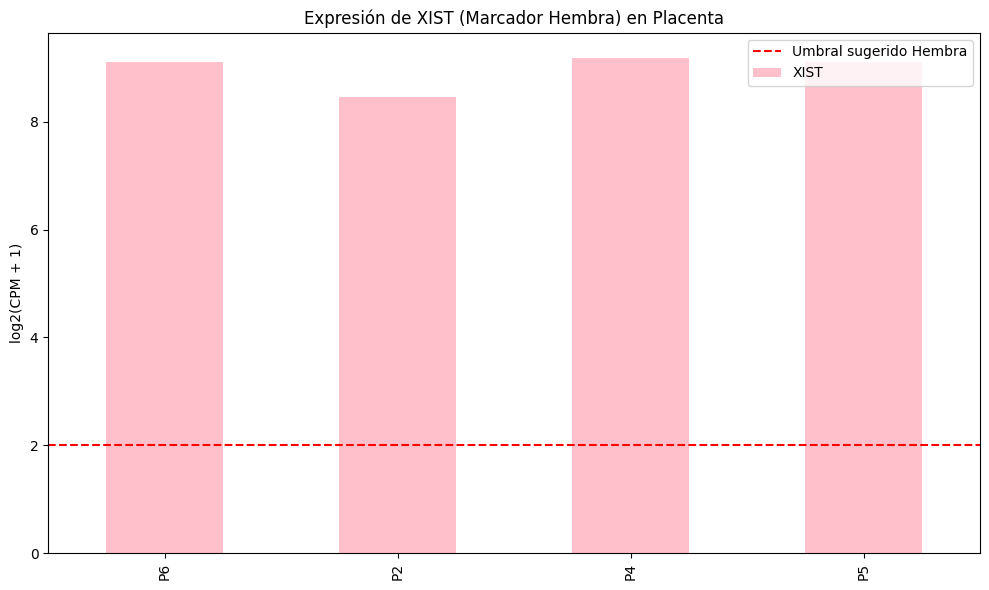


Predicción de sexo por muestra:
P6    Hembra
P2    Hembra
P4    Hembra
P5    Hembra
Name: XIST, dtype: object


In [6]:

# 1. Carga de datos corregida (usando coma)
# Leemos el archivo y usamos la segunda columna (índice 1) como el nombre del gen
df = pd.read_csv('GSE196917_RawCounts.csv', sep=',')

# Según lo que vimos en el error:
# Columna 0: ENSG... (ID Ensembl)
# Columna 1: Símbolo del gen (Name)
# Por lo tanto, establecemos la columna 1 como índice y borramos la columna 0
df.index = df.iloc[:, 1].str.strip() # Usamos la columna de símbolos como índice
df = df.drop(df.columns[[0, 1]], axis=1) # Borramos las dos primeras columnas descriptivas para dejar solo números

# 2. Normalización CPM (Counts Per Million)
# Esto es necesario para comparar muestras con distinto nivel de profundidad de secuenciación
cpm = df.divide(df.sum(axis=0), axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

# 3. Genes objetivo (Marcadores de sexo y placenta)
# Añadí RPS4Y1 y DDX3Y que son marcadores clave del cromosoma Y (Machos)
genes_objetivo = ['XIST', 'KDM6A', 'EIF1AX', 'RPS4Y1', 'DDX3Y', 'NLRP2', 'CYP19A1']

# Filtrar solo los que existen en la tabla
genes_encontrados = [g for g in genes_objetivo if g in log_cpm.index]
print(f"Genes encontrados para el análisis: {genes_encontrados}")

if not genes_encontrados:
    print("No se encontraron los genes. Revisa si los nombres están en mayúsculas.")
    print("Primeros genes disponibles:", df.index[:10].tolist())
else:
    # 4. Seleccionar datos de interés
    data_sex = log_cpm.loc[genes_encontrados].T
    
    # 5. Visualización: Heatmap comparativo
    plt.figure(figsize=(12, 10))
    sns.heatmap(data_sex.T, annot=True, cmap='RdBu_r', center=log_cpm.values.mean())
    plt.title("Diagnóstico de Sexo en Muestras GSE196917")
    plt.ylabel("Marcador Genético")
    plt.xlabel("ID de Muestra")
    plt.tight_layout()
    plt.savefig('heatmap_sexo.png')
    plt.show()

    # 6. Análisis específico de Placenta (Muestras que empiezan con 'P')
    muestras_placenta = [c for c in log_cpm.columns if c.startswith('P')]
    
    if muestras_placenta and 'XIST' in genes_encontrados:
        print("\n--- Análisis de XIST en Placenta ---")
        print(data_sex.loc[muestras_placenta, ['XIST']])
        
        # Gráfico de barras para XIST
        plt.figure(figsize=(10, 6))
        colors = ['pink' if v > 2 else 'lightblue' for v in data_sex.loc[muestras_placenta, 'XIST']]
        data_sex.loc[muestras_placenta, 'XIST'].plot(kind='bar', color=colors)
        plt.title("Expresión de XIST (Marcador Hembra) en Placenta")
        plt.ylabel("log2(CPM + 1)")
        plt.axhline(y=2, color='red', linestyle='--', label='Umbral sugerido Hembra')
        plt.legend()
        plt.tight_layout()
        plt.savefig('xist_placenta.png')
        plt.show()
        
        # Clasificación automática
        sexo_predicho = data_sex.loc[muestras_placenta, 'XIST'].apply(lambda x: 'Hembra' if x > 2 else 'Macho')
        print("\nPredicción de sexo por muestra:")
        print(sexo_predicho)